# **K-Means Clustering for Image Color Quantization**

# First we will import all the necessary packages.

In [1]:
import os
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Let's load our training image.

fatal: destination path '220105_k_means_clustering' already exists and is not an empty directory.
Original shape: (5046, 7569, 3)


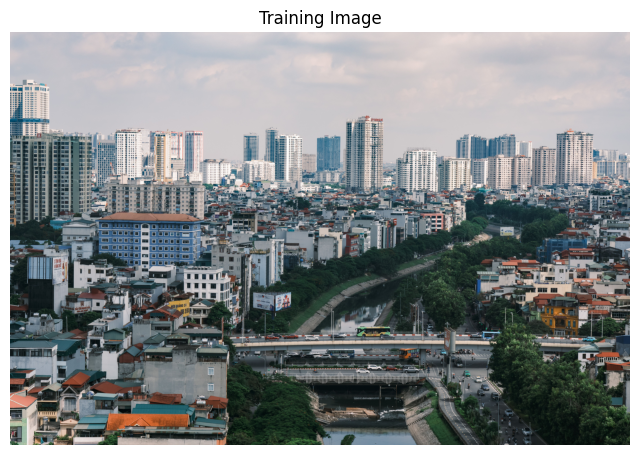

In [2]:
!git clone https://github.com/mdraihan27/220105_k_means_clustering.git
train_path = "/content/220105_k_means_clustering/dataset/train_image_from_pexels.jpg"

img = cv2.imread(train_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Original shape:", img.shape)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.title("Training Image")
plt.axis("off")
plt.show()

# Lets convert this image to pixel dataset.

K-Means clustering operates on numerical observations rather than image objects.

To prepare the image for clustering, every pixel is transformed into one observation consisting of three numerical features:

In [3]:
pixels = img.reshape((-1, 3))

print("Pixel dataset shape:", pixels.shape)

Pixel dataset shape: (38193174, 3)


# Let's scale pixel values.

As K-Means relies on Euclidean distance, feature scaling is applied to ensure balanced contribution from all color channels.

In [4]:
scaler = StandardScaler()

pixels_scaled = scaler.fit_transform(pixels)

print("Scaled shape:", pixels_scaled.shape)

Scaled shape: (38193174, 3)


# Let's validate scaling.

In [5]:
print("Minimum:", pixels_scaled.min())
print("Maximum:", pixels_scaled.max())
print("Mean:", pixels_scaled.mean())

Minimum: -1.8222511942435595
Maximum: 1.9218900668306085
Mean: -1.2295851328314622e-15


# Let's do exploratory data analysis.

In [6]:
print("Image Shape:", img.shape)

height, width, channels = img.shape

print("Height:", height)
print("Width:", width)
print("Channels:", channels)

print("Total Pixels:", height * width)

Image Shape: (5046, 7569, 3)
Height: 5046
Width: 7569
Channels: 3
Total Pixels: 38193174


Let's view pixel statistics.

In [7]:
import pandas as pd

pixel_df = pd.DataFrame(
    pixels,
    columns=[
        "Red",
        "Green",
        "Blue"
    ]
)

pixel_df.describe()

,Red,Green,Blue
count,3.819317e+07,3.819317e+07,3.819317e+07
mean,1.196669e+02,1.241070e+02,1.251702e+02
std,7.621989e+01,6.810641e+01,7.010696e+01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.300000e+01,5.600000e+01,5.300000e+01
50%,1.170000e+02,1.240000e+02,1.310000e+02
75%,1.990000e+02,1.970000e+02,2.010000e+02
max,2.550000e+02,2.550000e+02,2.550000e+02


Let's view RGB histograms.

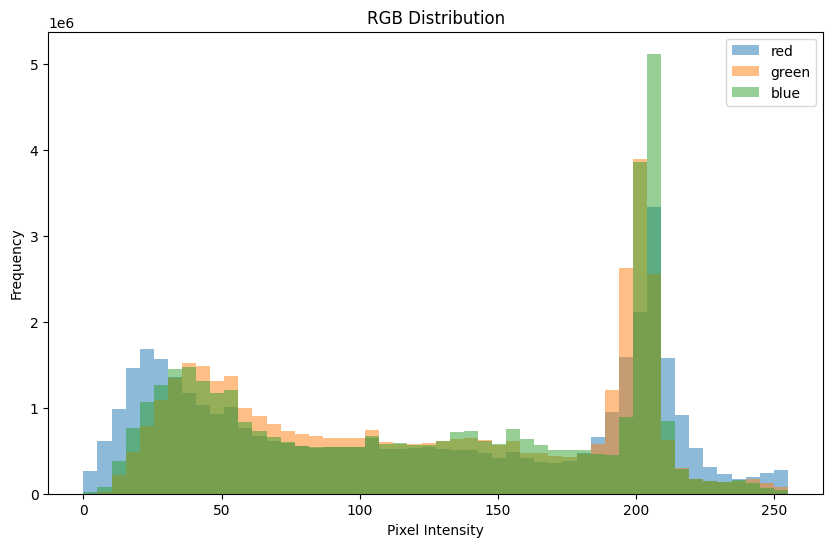

In [8]:
plt.figure(figsize=(10,6))

colors = ["red", "green", "blue"]

for i, color in enumerate(colors):

    plt.hist(
        pixels[:, i],
        bins=50,
        alpha=0.5,
        label=color
    )

plt.title(
    "RGB Distribution"
)

plt.xlabel("Pixel Intensity")

plt.ylabel("Frequency")

plt.legend()

plt.show()

# Let's reduce runtime to make elbow method faster.

Because image datasets contain millions of pixels, a subset of pixels is sampled to accelerate the Elbow Method without significantly affecting cluster selection.

In [9]:
sample_size = 10000

idx = np.random.choice(
    len(pixels_scaled),
    sample_size,
    replace=False
)

pixels_sample = pixels_scaled[idx]

print("Sample shape:", pixels_sample.shape)

Sample shape: (10000, 3)


# Let's determine optimal k using elbow method.

Elbow Method is used to determine the optimal value of K automatically.

In [10]:
wcss = []

k_values = range(2, 11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(pixels_sample)

    wcss.append(model.inertia_)

print("Finished.")

Finished.


Let's plot the elbow curve.

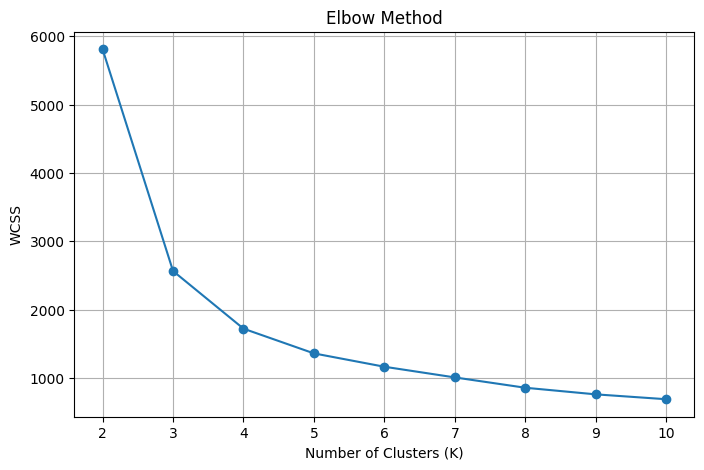

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid()

plt.show()

Let's determine the optimal K.

In [12]:
from sklearn.metrics import pairwise_distances

x = np.array(list(k_values))
y = np.array(wcss)

p1 = np.array([x[0], y[0]])
p2 = np.array([x[-1], y[-1]])

distances = []

for i in range(len(x)):

    p = np.array([x[i], y[i]])

    distance = (
        np.abs(
            np.cross(
                p2 - p1,
                p1 - p
            )
        )
        /
        np.linalg.norm(
            p2 - p1
        )
    )

    distances.append(distance)

optimal_k = x[np.argmax(distances)]

print("Automatically selected K =", optimal_k)

Automatically selected K = 4


/tmp/ipykernel_18936/828147632.py:17: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  np.cross(


# Now, we will train our full scaled dataset with out k-means model.

Using the automatically selected K value, the final K-Means model is trained on the complete standardized pixel dataset.

In [13]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans.fit(pixels_scaled)

print("Training completed.")

print("Number of clusters:", optimal_k)
print("Centroid shape:", kmeans.cluster_centers_.shape)

Training completed.
Number of clusters: 4
Centroid shape: (4, 3)


Let's view centroid colors.

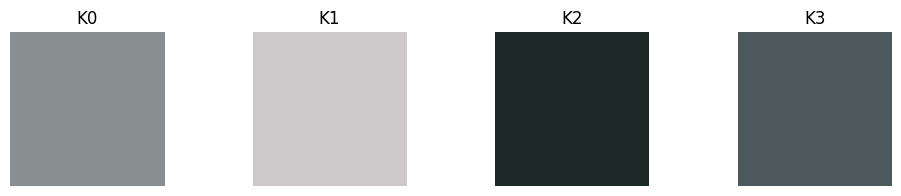

In [14]:
centroid_rgb = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centroid_rgb = np.clip(
    centroid_rgb,
    0,
    255
).astype(np.uint8)

plt.figure(
    figsize=(12,2)
)

for i, color in enumerate(centroid_rgb):

    plt.subplot(
        1,
        optimal_k,
        i+1
    )

    plt.imshow(
        [[color]]
    )

    plt.title(
        f"K{i}"
    )

    plt.axis("off")

plt.show()

# Let's create the model folder.

In [15]:
import os

os.makedirs(
    "/content/k-means-model",
    exist_ok=True
)

Let's save the trained model and scaler.

In [16]:
joblib.dump(
    kmeans,
    "/content/k-means-model/k_means_model.pkl"
)

joblib.dump(
    scaler,
    "/content/k-means-model/scaler.pkl"
)

print("Model and scaler saved.")

print(
    os.listdir(
        "/content/k-means-model"
    )
)

Model and scaler saved.
['k_means_model.pkl', 'scaler.pkl']


This model annd scaler we saved, we will upload this to our github later.

# Now, we will train on our custom image.

I will test the model with an image I clicked myself.

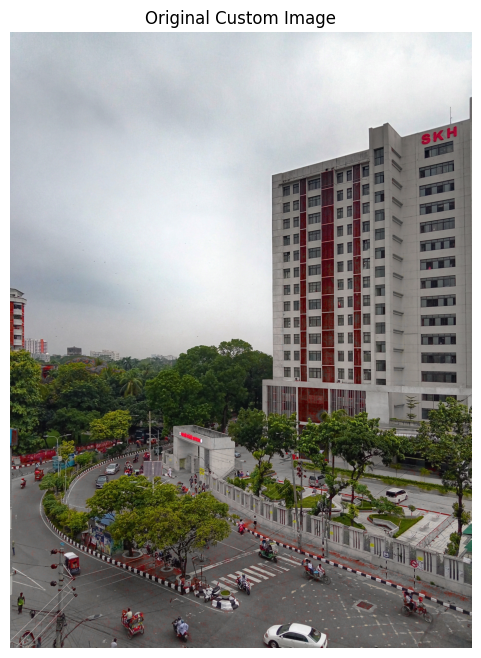

In [17]:
custom_path = "/content/220105_k_means_clustering/dataset/test_image_by_raihan.jpg"

custom_img = cv2.imread(custom_path)

if custom_img is None:
    raise FileNotFoundError("Custom image not found.")

custom_img = cv2.cvtColor(
    custom_img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8,8))
plt.imshow(custom_img)
plt.title("Original Custom Image")
plt.axis("off")
plt.show()

# Convert custom image into pixel dataset.

In [18]:
original_shape = custom_img.shape

custom_pixels = custom_img.reshape((-1, 3))

print("Custom pixel shape:", custom_pixels.shape)

Custom pixel shape: (12009000, 3)


# Apply the same scaler here.

In [19]:
custom_scaled = scaler.transform(
    custom_pixels
)

# Now, we will attempt to predict cluster IDs.

In [20]:
cluster_labels = kmeans.predict(
    custom_scaled
)

print(cluster_labels.shape)

(12009000,)


# Let's rebuild the compressed image.

Cluster assignments are converted back into representative colors using centroid values.

In [21]:
compressed_scaled = (
    kmeans.cluster_centers_[cluster_labels]
)

compressed_pixels = scaler.inverse_transform(
    compressed_scaled
)

compressed_pixels = np.clip(
    compressed_pixels,
    0,
    255
).astype(np.uint8)

# Restore image dimensions.

In [22]:
compressed_img = compressed_pixels.reshape(
    original_shape
)

# Let's have a view of before and after.

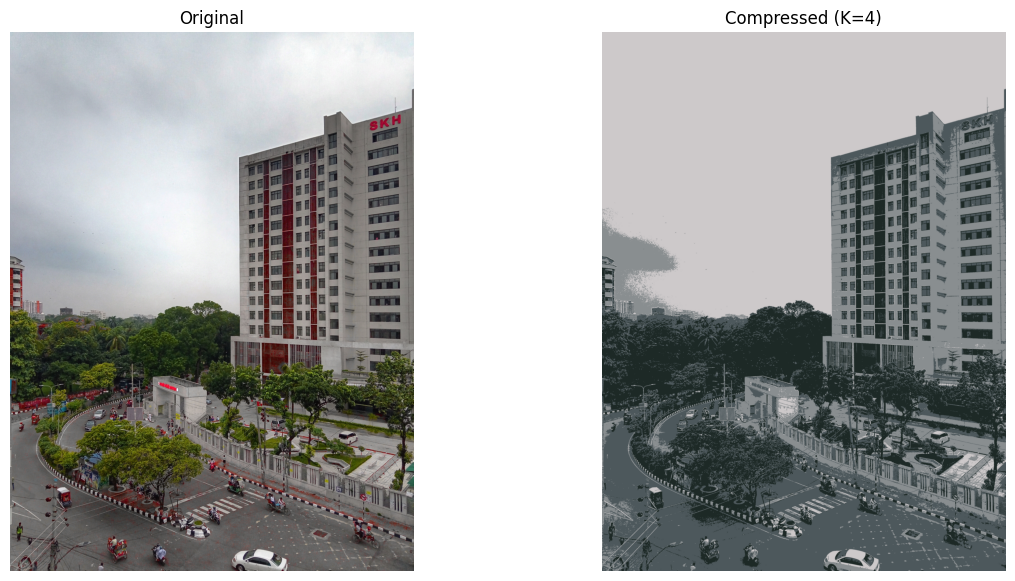

In [23]:
plt.figure(figsize=(14,7))

plt.subplot(1,2,1)

plt.imshow(custom_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(compressed_img)
plt.title(
    f"Compressed (K={optimal_k})"
)
plt.axis("off")

plt.show()

Let's save the custom compressed image.

In [24]:
output_path = "/content/outputs/compressed_output.jpg"

cv2.imwrite(
    output_path,
    cv2.cvtColor(
        compressed_img,
        cv2.COLOR_RGB2BGR
    )
)

print("Saved:", output_path)

Saved: /content/outputs/compressed_output.jpg


# Let's create cluster distribution table.

In [25]:
import pandas as pd

cluster_table = pd.DataFrame({
    "Cluster": np.arange(optimal_k),
    "Pixel_Count": np.bincount(
        cluster_labels
    )
})

cluster_table["Percentage"] = (
    cluster_table["Pixel_Count"]
    /
    cluster_table["Pixel_Count"].sum()
) * 100

cluster_table

,Cluster,Pixel_Count,Percentage
0,0,2164496,18.023949
1,1,4418773,36.795512
2,2,2539827,21.149363
3,3,2885904,24.031177


# Create cluster scatter plot.

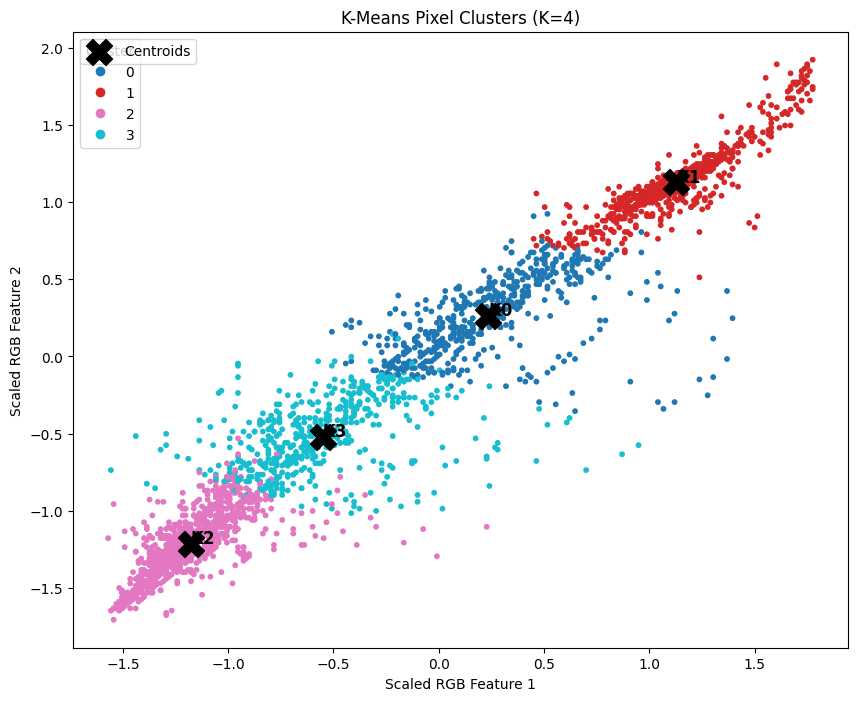

In [26]:
sample_vis = pixels_sample[:3000]

vis_labels = kmeans.predict(sample_vis)

centroids = kmeans.cluster_centers_

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    sample_vis[:, 0],
    sample_vis[:, 1],
    c=vis_labels,
    cmap="tab10",
    s=10
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="black",
    marker="X",
    s=350,
    label="Centroids"
)

# Label centroids
for i, center in enumerate(centroids):
    plt.text(
        center[0],
        center[1],
        f"K{i}",
        fontsize=12,
        weight="bold"
    )

plt.xlabel("Scaled RGB Feature 1")
plt.ylabel("Scaled RGB Feature 2")

plt.title(
    f"K-Means Pixel Clusters (K={optimal_k})"
)

# Legend for cluster colors
legend = plt.legend(
    *scatter.legend_elements(),
    title="Cluster"
)

plt.gca().add_artist(legend)

plt.legend()

plt.show()

# Cluster Interpretation:

# Cluster 0 represents trasitional colors.

# Cluster 1 captures represents one dominant color family.

# Cluster 2 captures represents secondary or transitional tones.

# Cluster 3 represents secondary or transitional tones.

# Overall, K-Means reduced image complexity while preserving visual appearance.